# PROYECTO FINAL DE ANÁLISIS DE DATOS - NIVEL INTEGRADOR
**Programa:** TALENTO TECH

**Equipo de Trabajo:**

---

## Fase 1: Identificación de la Problemática
Para este proyecto integrador, hemos seleccionado la línea de investigación enfocada en Tecnologías de la Información y la Comunicación (TIC) para la transformación productiva[cite: 12].

**Problema seleccionado:** Análisis del comportamiento de usuarios y efectividad en la resolución de incidencias en plataformas de atención al cliente (análisis de "re-llamadas" o reincidencia)[cite: 32].

Este análisis es fundamental en operaciones de atención masiva, ya que una alta tasa de re-llamadas impacta negativamente la experiencia del usuario y eleva los costos operativos de la plataforma. [cite_start]El objetivo es utilizar bases de datos y técnicas de análisis para identificar patrones de reincidencia según el nivel de experiencia del agente, el tipo de incidencia y el plan del usuario[cite: 9, 14].

In [ ]:
# Importar librerías base
import pandas as pd
import sqlite3

# Cargar la extensión de SQL para Jupyter/Colab
%load_ext sql

# Crear y conectar a una base de datos local llamada "proyecto_tic.db"
%sql sqlite:///proyecto_tic.db

## Fase 2: Creación y Gestión de la Base de Datos
Para almacenar la información necesaria, hemos diseñado una base de datos relacional utilizando un **Modelo de Estrella (Star Schema)**. Esto asegura la consistencia y normalización de los datos provenientes de las plataformas de atención[cite: 36].

El modelo consta de:
* **3 Tablas de Dimensiones:** `Dim_Usuarios`, `Dim_Agentes`, y `Dim_Tipo_Incidencia`.
* **1 Tabla de Hechos:** `Fact_Interacciones`, que registra cada llamada y contiene la variable clave `es_rellamada`.

In [ ]:
%%sql
-- Eliminar tablas si ya existen
DROP TABLE IF EXISTS Fact_Interacciones;
DROP TABLE IF EXISTS Dim_Usuarios;
DROP TABLE IF EXISTS Dim_Agentes;
DROP TABLE IF EXISTS Dim_Tipo_Incidencia;

-- Dimensión 1: Usuarios
CREATE TABLE Dim_Usuarios (
    id_usuario INT PRIMARY KEY,
    nombre VARCHAR(100),
    fecha_registro DATE,
    plan_servicio VARCHAR(50)
);

-- Dimensión 2: Agentes
CREATE TABLE Dim_Agentes (
    id_agente INT PRIMARY KEY,
    nombre VARCHAR(100),
    nivel_experiencia VARCHAR(50),
    turno VARCHAR(20)
);

-- Dimensión 3: Tipo de Incidencia
CREATE TABLE Dim_Tipo_Incidencia (
    id_tipo_incidencia INT PRIMARY KEY,
    categoria VARCHAR(50),
    descripcion VARCHAR(200),
    prioridad VARCHAR(20)
);

-- Tabla de Hechos: Interacciones
CREATE TABLE Fact_Interacciones (
    id_interaccion INT PRIMARY KEY,
    id_usuario INT,
    id_agente INT,
    id_tipo_incidencia INT,
    fecha_hora TIMESTAMP,
    duracion_segundos INT,
    resuelta_en_primera_llamada INT,
    es_rellamada INT,
    FOREIGN KEY (id_usuario) REFERENCES Dim_Usuarios(id_usuario),
    FOREIGN KEY (id_agente) REFERENCES Dim_Agentes(id_agente),
    FOREIGN KEY (id_tipo_incidencia) REFERENCES Dim_Tipo_Incidencia(id_tipo_incidencia)
);

 * sqlite:///proyecto_tic.db
Done.
Done.
Done.
Done.
Done.
Done.
Done.
Done.


[]

In [ ]:
import sqlite3
import random
from datetime import datetime, timedelta

# Conectar a la base de datos local de Colab
conn = sqlite3.connect('proyecto_tic.db')
cursor = conn.cursor()

# 1. Generar 200 Usuarios con nombres reales
nombres = ['Carlos', 'Maria', 'Luis', 'Ana', 'Jorge', 'Diana', 'Andres', 'Laura', 'Diego', 'Camila', 'Santiago', 'Valentina', 'Alejandro', 'Daniela', 'Juan', 'Sofia']
apellidos = ['Ramirez', 'Gomez', 'Fernandez', 'Martinez', 'Perez', 'Garcia', 'Rojas', 'Castro', 'Lopez', 'Diaz', 'Hernandez', 'Garces', 'Osorio', 'Vargas']
planes = ['Basico', 'Premium', 'Corporativo']

usuarios = []
for i in range(1, 201):
    nombre_completo = f"{random.choice(nombres)} {random.choice(apellidos)}"
    fecha_reg = (datetime(2024, 1, 1) + timedelta(days=random.randint(0, 400))).strftime('%Y-%m-%d')
    usuarios.append((i, nombre_completo, fecha_reg, random.choice(planes)))

cursor.executemany('INSERT INTO Dim_Usuarios VALUES (?,?,?,?)', usuarios)

# 2. Generar 30 Agentes Operativos
niveles = ['Junior', 'Semi-Senior', 'Senior']
turnos = ['Mañana', 'Tarde', 'Noche']

agentes = []
for i in range(101, 131):
    nombre_completo = f"{random.choice(nombres)} {random.choice(apellidos)}"
    agentes.append((i, nombre_completo, random.choice(niveles), random.choice(turnos)))

cursor.executemany('INSERT INTO Dim_Agentes VALUES (?,?,?,?)', agentes)

# 3. Insertar 10 Tipos de Incidencia Reales (TIC/Telecom)
incidencias = [
    (10, 'Facturacion', 'Cobro doble en tarjeta de credito', 'Alta'),
    (11, 'Facturacion', 'No aplicacion de pago reciente', 'Media'),
    (20, 'Soporte Tecnico', 'Caida masiva de internet hogar', 'Critica'),
    (21, 'Soporte Tecnico', 'Intermitencia en red WiFi', 'Alta'),
    (22, 'Soporte Tecnico', 'Configuracion de router nuevo', 'Media'),
    (30, 'Informacion', 'Consulta de gigas disponibles', 'Baja'),
    (31, 'Informacion', 'Requisitos para cambio de plan', 'Baja'),
    (40, 'Retencion', 'Intencion de cancelacion por precio', 'Alta'),
    (41, 'Retencion', 'Inconformidad con atencion previa', 'Media'),
    (50, 'Ventas', 'Adicion de linea adicional', 'Media')
]
cursor.executemany('INSERT INTO Dim_Tipo_Incidencia VALUES (?,?,?,?)', incidencias)

# 4. Generar 1,000 Interacciones (Simulando Re-llamadas)
interacciones = []
fecha_base = datetime(2025, 1, 1)

for i in range(1, 1001):
    id_usuario = random.randint(1, 200)
    id_agente = random.randint(101, 130)
    id_incidencia = random.choice([10, 11, 20, 21, 22, 30, 31, 40, 41, 50])

    # Simular fecha, hora y duración (TMO)
    fecha_hora = fecha_base + timedelta(days=random.randint(0, 90), hours=random.randint(6, 22), minutes=random.randint(0, 59))
    duracion = random.randint(120, 1500) # Entre 2 y 25 minutos

    # Lógica operativa: Si no se resuelve en primera llamada (0), hay alta chance de que sea una re-llamada (1)
    resuelta = random.choice([0, 1])
    es_rellamada = 1 if (resuelta == 0 and random.random() > 0.3) else 0

    interacciones.append((
        i, id_usuario, id_agente, id_incidencia,
        fecha_hora.strftime('%Y-%m-%d %H:%M:%S'),
        duracion, resuelta, es_rellamada
    ))

cursor.executemany('INSERT INTO Fact_Interacciones VALUES (?,?,?,?,?,?,?,?)', interacciones)

# Guardar cambios
conn.commit()

# Verificación rápida del volumen de datos
cursor.execute("SELECT COUNT(*) FROM Fact_Interacciones")
total_registros = cursor.fetchone()[0]
print(f"¡Éxito! Base de datos poblada con {total_registros} interacciones, 200 usuarios y 30 agentes.")

¡Éxito! Base de datos poblada con 1000 interacciones, 200 usuarios y 30 agentes.


## Fase 3: Análisis de Datos (Consultas SQL)
En esta fase, ejecutaremos consultas SQL complejas sobre el modelo de estrella previamente construido para extraer información relevante y generar insights. Las consultas hacen uso de subconsultas, JOINS, funciones agregadas y filtros avanzados para responder a preguntas de negocio clave sobre la operación y las re-llamadas.

In [ ]:
import sqlite3
import pandas as pd
from IPython.display import display, Markdown

# Conectar a la base de datos local
conn = sqlite3.connect('proyecto_tic.db')

# Lista con todas las consultas, sus títulos y explicaciones
consultas_analisis = [
    {
        "titulo": "1. Tasa de Reincidencia por Nivel de Experiencia",
        "explicacion": "Utiliza un `JOIN` y funciones agregadas para identificar si los agentes con menor experiencia generan un mayor volumen de re-llamadas.",
        "sql": """
            SELECT
                a.nivel_experiencia,
                COUNT(f.id_interaccion) AS total_llamadas_atendidas,
                SUM(f.es_rellamada) AS total_rellamadas,
                ROUND((SUM(f.es_rellamada) * 100.0) / COUNT(f.id_interaccion), 2) AS porcentaje_reincidencia
            FROM Fact_Interacciones f
            INNER JOIN Dim_Agentes a ON f.id_agente = a.id_agente
            GROUP BY a.nivel_experiencia
            ORDER BY porcentaje_reincidencia DESC;
        """
    },
    {
        "titulo": "2. Impacto de la Reincidencia en los Planes de Servicio",
        "explicacion": "Mide qué segmento de clientes (Básico, Premium, etc.) está sufriendo más re-llamadas, evaluando el riesgo de insatisfacción.",
        "sql": """
            SELECT
                u.plan_servicio,
                COUNT(DISTINCT u.id_usuario) AS usuarios_afectados,
                SUM(f.es_rellamada) AS volumen_rellamadas,
                ROUND(AVG(f.duracion_segundos) / 60.0, 2) AS duracion_prom_minutos
            FROM Fact_Interacciones f
            INNER JOIN Dim_Usuarios u ON f.id_usuario = u.id_usuario
            WHERE f.es_rellamada = 1
            GROUP BY u.plan_servicio
            ORDER BY volumen_rellamadas DESC;
        """
    },
    {
        "titulo": "3. FCR (First Call Resolution) por Turno Operativo",
        "explicacion": "Evalúa la efectividad resolutiva en el primer contacto agrupando por el turno del agente.",
        "sql": """
            SELECT
                a.turno,
                COUNT(f.id_interaccion) AS total_llamadas,
                SUM(f.resuelta_en_primera_llamada) AS resueltas_primer_contacto,
                ROUND((SUM(f.resuelta_en_primera_llamada) * 100.0) / COUNT(f.id_interaccion), 2) AS fcr_porcentaje
            FROM Fact_Interacciones f
            INNER JOIN Dim_Agentes a ON f.id_agente = a.id_agente
            GROUP BY a.turno
            ORDER BY fcr_porcentaje ASC;
        """
    },
    {
        "titulo": "4. Tiempo Perdido en Llamadas No Resueltas por Categoría",
        "explicacion": "Hace uso de una subconsulta (CTE) para aislar llamadas no resueltas y calcular el impacto en minutos perdidos por categoría.",
        "sql": """
            WITH LlamadasNoResueltas AS (
                SELECT id_tipo_incidencia, duracion_segundos
                FROM Fact_Interacciones
                WHERE resuelta_en_primera_llamada = 0
            )
            SELECT
                t.categoria,
                COUNT(lnr.id_tipo_incidencia) AS cantidad_no_resueltas,
                ROUND(SUM(lnr.duracion_segundos) / 60.0, 2) AS minutos_totales_perdidos
            FROM LlamadasNoResueltas lnr
            INNER JOIN Dim_Tipo_Incidencia t ON lnr.id_tipo_incidencia = t.id_tipo_incidencia
            GROUP BY t.categoria
            HAVING COUNT(lnr.id_tipo_incidencia) > 10
            ORDER BY minutos_totales_perdidos DESC;
        """
    },
    {
        "titulo": "5. Top de Usuarios Críticos (Múltiples Reincidencias)",
        "explicacion": "Filtra la base de datos mediante otra CTE para encontrar a los 5 usuarios que más han tenido que re-llamar a la plataforma.",
        "sql": """
            WITH ConteoUsuarios AS (
                SELECT
                    u.id_usuario, u.nombre, u.plan_servicio,
                    COUNT(f.id_interaccion) AS total_interacciones,
                    SUM(f.es_rellamada) AS total_rellamadas
                FROM Fact_Interacciones f
                INNER JOIN Dim_Usuarios u ON f.id_usuario = u.id_usuario
                GROUP BY u.id_usuario, u.nombre, u.plan_servicio
            )
            SELECT * FROM ConteoUsuarios
            WHERE total_rellamadas >= 2
            ORDER BY total_rellamadas DESC
            LIMIT 5;
        """
    },
    {
        "titulo": "6. Segmentación Operativa de la Base de Interacciones",
        "explicacion": "Utiliza una declaración `CASE` avanzada para clasificar la operación en segmentos clave según el tiempo de contacto y la antigüedad del cliente.",
        "sql": """
            SELECT
                CASE
                    WHEN u.fecha_registro >= '2025-01-01' THEN 'A: Clientes nuevos'
                    WHEN f.duracion_segundos = 0 THEN 'B: No contacto'
                    WHEN f.duracion_segundos > 180 THEN 'C: Contacto con TMO > 3 Min'
                    ELSE 'D: restantes'
                END AS segmento_operativo,
                COUNT(f.id_interaccion) AS volumen_interacciones,
                ROUND(AVG(f.duracion_segundos), 2) AS tmo_promedio_segundos
            FROM Fact_Interacciones f
            JOIN Dim_Usuarios u ON f.id_usuario = u.id_usuario
            GROUP BY segmento_operativo
            ORDER BY volumen_interacciones DESC;
        """
    },
    {
        "titulo": "7. Matriz de Riesgo: Prioridad vs. Nivel de Experiencia",
        "explicacion": "Cruza múltiples tablas para observar cuántas incidencias críticas cayeron en manos de agentes junior y no se resolvieron.",
        "sql": """
            SELECT
                t.prioridad,
                a.nivel_experiencia,
                COUNT(f.id_interaccion) AS total_casos,
                SUM(CASE WHEN f.resuelta_en_primera_llamada = 0 THEN 1 ELSE 0 END) AS casos_no_resueltos
            FROM Fact_Interacciones f
            INNER JOIN Dim_Tipo_Incidencia t ON f.id_tipo_incidencia = t.id_tipo_incidencia
            INNER JOIN Dim_Agentes a ON f.id_agente = a.id_agente
            GROUP BY t.prioridad, a.nivel_experiencia
            ORDER BY t.prioridad, casos_no_resueltos DESC;
        """
    },
    {
        "titulo": "8. Saturación Diaria y Porcentaje de Reincidencia",
        "explicacion": "Agrupa por fecha exacta para identificar los días de mayor colapso o picos anormales de re-llamadas.",
        "sql": """
            SELECT
                DATE(f.fecha_hora) AS fecha_dia,
                COUNT(f.id_interaccion) AS volumen_total,
                SUM(f.es_rellamada) AS volumen_rellamadas,
                ROUND((SUM(f.es_rellamada) * 100.0) / COUNT(f.id_interaccion), 2) AS porcentaje_diario_rellamadas
            FROM Fact_Interacciones f
            GROUP BY DATE(f.fecha_hora)
            ORDER BY volumen_total DESC
            LIMIT 10;
        """
    },
    {
        "titulo": "9. AHT (Tiempo Medio de Operación): Primera Llamada vs. Re-llamada",
        "explicacion": "Compara el tiempo que toma atender una primera llamada versus el tiempo que consume una re-llamada.",
        "sql": """
            SELECT
                t.categoria,
                CASE WHEN f.es_rellamada = 1 THEN 'Re-llamada' ELSE 'Primera Llamada' END AS tipo_contacto,
                COUNT(f.id_interaccion) AS volumen,
                ROUND(AVG(f.duracion_segundos), 2) AS aht_promedio_segundos
            FROM Fact_Interacciones f
            INNER JOIN Dim_Tipo_Incidencia t ON f.id_tipo_incidencia = t.id_tipo_incidencia
            GROUP BY t.categoria, f.es_rellamada
            ORDER BY t.categoria, tipo_contacto;
        """
    },
    {
        "titulo": "10. Tasa de Falla en Agentes Junior por Turno",
        "explicacion": "Usa una subconsulta en la cláusula `FROM` para aislar el rendimiento de los agentes Junior y ver en qué turno fallan más.",
        "sql": """
            SELECT
                Sub.turno,
                Sub.total_llamadas_junior,
                Sub.rellamadas_junior,
                ROUND((Sub.rellamadas_junior * 100.0) / Sub.total_llamadas_junior, 2) AS tasa_falla_junior
            FROM (
                SELECT
                    a.turno,
                    COUNT(f.id_interaccion) AS total_llamadas_junior,
                    SUM(f.es_rellamada) AS rellamadas_junior
                FROM Fact_Interacciones f
                INNER JOIN Dim_Agentes a ON f.id_agente = a.id_agente
                WHERE a.nivel_experiencia = 'Junior'
                GROUP BY a.turno
            ) AS Sub
            WHERE Sub.total_llamadas_junior > 0
            ORDER BY tasa_falla_junior DESC;
        """
    }
]

# Ejecutar iterativamente, imprimir la explicación y mostrar la tabla de resultados
for consulta in consultas_analisis:
    display(Markdown(f"### {consulta['titulo']}"))
    display(Markdown(f"**¿Qué hace esta consulta?** {consulta['explicacion']}"))

    # Leer SQL directo a Pandas DataFrame
    df_resultado = pd.read_sql_query(consulta['sql'], conn)

    # Mostrar la tabla estilizada en Colab
    display(df_resultado)
    display(Markdown("---")) # Línea separadora

### 1. Tasa de Reincidencia por Nivel de Experiencia

**¿Qué hace esta consulta?** Utiliza un `JOIN` y funciones agregadas para identificar si los agentes con menor experiencia generan un mayor volumen de re-llamadas.

,nivel_experiencia,total_llamadas_atendidas,total_rellamadas,porcentaje_reincidencia
0,Senior,376,145,38.56
1,Semi-Senior,202,72,35.64
2,Junior,422,138,32.70


---

### 2. Impacto de la Reincidencia en los Planes de Servicio

...

---

### 10. Tasa de Falla en Agentes Junior por Turno

**¿Qué hace esta consulta?** Usa una subconsulta en la cláusula `FROM` para aislar el rendimiento de los agentes Junior y ver en qué turno fallan más.

,turno,total_llamadas_junior,rellamadas_junior,tasa_falla_junior
0,Mañana,113,44,38.94
1,Noche,167,54,32.34
2,Tarde,142,40,28.17


---

### Exploración de Datos (EDA) con Pandas
Antes de proceder con la visualización, es fundamental realizar un Análisis Exploratorio de Datos (EDA) para comprender la estructura general de nuestra información. Utilizaremos Pandas para cargar una vista consolidada de la base de datos (uniendo la tabla de hechos con sus dimensiones) y extraeremos las estadísticas descriptivas principales.

In [6]:
import pandas as pd
import sqlite3
from IPython.display import display, Markdown

# 1. Conectar a la base de datos
conn = sqlite3.connect('proyecto_tic.db')

# 2. Consulta SQL para traer el dataset consolidado (Tabla Plana)
query_eda = """
    SELECT
        f.id_interaccion,
        u.plan_servicio,
        a.nivel_experiencia,
        a.turno,
        t.categoria,
        t.prioridad,
        f.duracion_segundos,
        f.resuelta_en_primera_llamada,
        f.es_rellamada
    FROM Fact_Interacciones f
    JOIN Dim_Usuarios u ON f.id_usuario = u.id_usuario
    JOIN Dim_Agentes a ON f.id_agente = a.id_agente
    JOIN Dim_Tipo_Incidencia t ON f.id_tipo_incidencia = t.id_tipo_incidencia
"""

# Leer los datos con Pandas
df_consolidado = pd.read_sql_query(query_eda, conn)

# 3. Mostrar el Head (Primeros 5 registros)
display(Markdown("**1. Muestra de los Datos (df.head())**"))
display(Markdown("Visualizamos las primeras filas para confirmar que los cruces (JOINS) trajeron la información correcta de las dimensiones."))
display(df_consolidado.head())

# 4. Mostrar la estructura e información de las columnas
display(Markdown("---"))
display(Markdown("**2. Estructura del Dataset y Valores Nulos**"))
info_df = pd.DataFrame({
    'Tipo de Dato': df_consolidado.dtypes,
    'Valores Nulos': df_consolidado.isnull().sum()
})
display(info_df)

# 5. Mostrar los Estadísticos Principales (Describe)
display(Markdown("---"))
display(Markdown("**3. Estadísticos Principales (df.describe())**"))
display(Markdown("Aquí analizamos las medidas de tendencia central y dispersión de nuestras variables numéricas (como el TMO en `duracion_segundos`)."))
# Redondeamos a 2 decimales para que se vea mucho más limpio
display(df_consolidado.describe().round(2))

# Cerrar la conexión
conn.close()

**1. Muestra de los Datos (df.head())**

Visualizamos las primeras filas para confirmar que los cruces (JOINS) trajeron la información correcta de las dimensiones.

,id_interaccion,plan_servicio,nivel_experiencia,turno,categoria,prioridad,duracion_segundos,resuelta_en_primera_llamada,es_rellamada
0,1,Corporativo,Junior,Noche,Soporte Tecnico,Critica,1475,1,0
1,2,Corporativo,Junior,Noche,Soporte Tecnico,Critica,473,0,0
2,3,Premium,Junior,Mañana,Soporte Tecnico,Critica,1480,0,1
3,4,Basico,Semi-Senior,Noche,Facturacion,Media,980,1,0
4,5,Premium,Senior,Mañana,Soporte Tecnico,Critica,1420,1,0


---

**2. Estructura del Dataset y Valores Nulos**

,Tipo de Dato,Valores Nulos
id_interaccion,int64,0
plan_servicio,object,0
nivel_experiencia,object,0
turno,object,0
categoria,object,0
prioridad,object,0
duracion_segundos,int64,0
resuelta_en_primera_llamada,int64,0
es_rellamada,int64,0


---

**3. Estadísticos Principales (df.describe())**

Aquí analizamos las medidas de tendencia central y dispersión de nuestras variables numéricas (como el TMO en `duracion_segundos`).

,id_interaccion,duracion_segundos,resuelta_en_primera_llamada,es_rellamada
count,1000.00,1000.00,1000.00,1000.00
mean,500.50,818.17,0.48,0.36
std,288.82,407.42,0.50,0.48
min,1.00,120.00,0.00,0.00
25%,250.75,456.00,0.00,0.00
50%,500.50,818.50,0.00,0.00
75%,750.25,1177.25,1.00,1.00
max,1000.00,1500.00,1.00,1.00


## Fase 4: Visualización de Datos
Para esta etapa, hemos extraído los resultados de nuestras consultas SQL utilizando Pandas y los hemos integrado con las librerías **Matplotlib** y **Seaborn**.

El objetivo es diseñar visualizaciones que representen los resultados del análisis de manera clara y efectiva [cite_start], permitiendo explorar las hipótesis relacionadas con la generación de re-llamadas en la plataforma de atención TIC. A continuación, se presenta un dashboard con los indicadores más críticos de la operación.

/tmp/ipykernel_3103/1181107291.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df1, x='nivel_experiencia', y='pct_rellamada', ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_3103/1181107291.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df2, x='total_rellamadas', y='categoria', ax=axes[0, 1], palette='magma')
/tmp/ipykernel_3103/1181107291.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df4, x='tipo_contacto', y='duracion_segundos', ax=axes[1, 1], palette='Set2')
/tmp/ipykernel_3103/1181107291.py:93: FutureWar

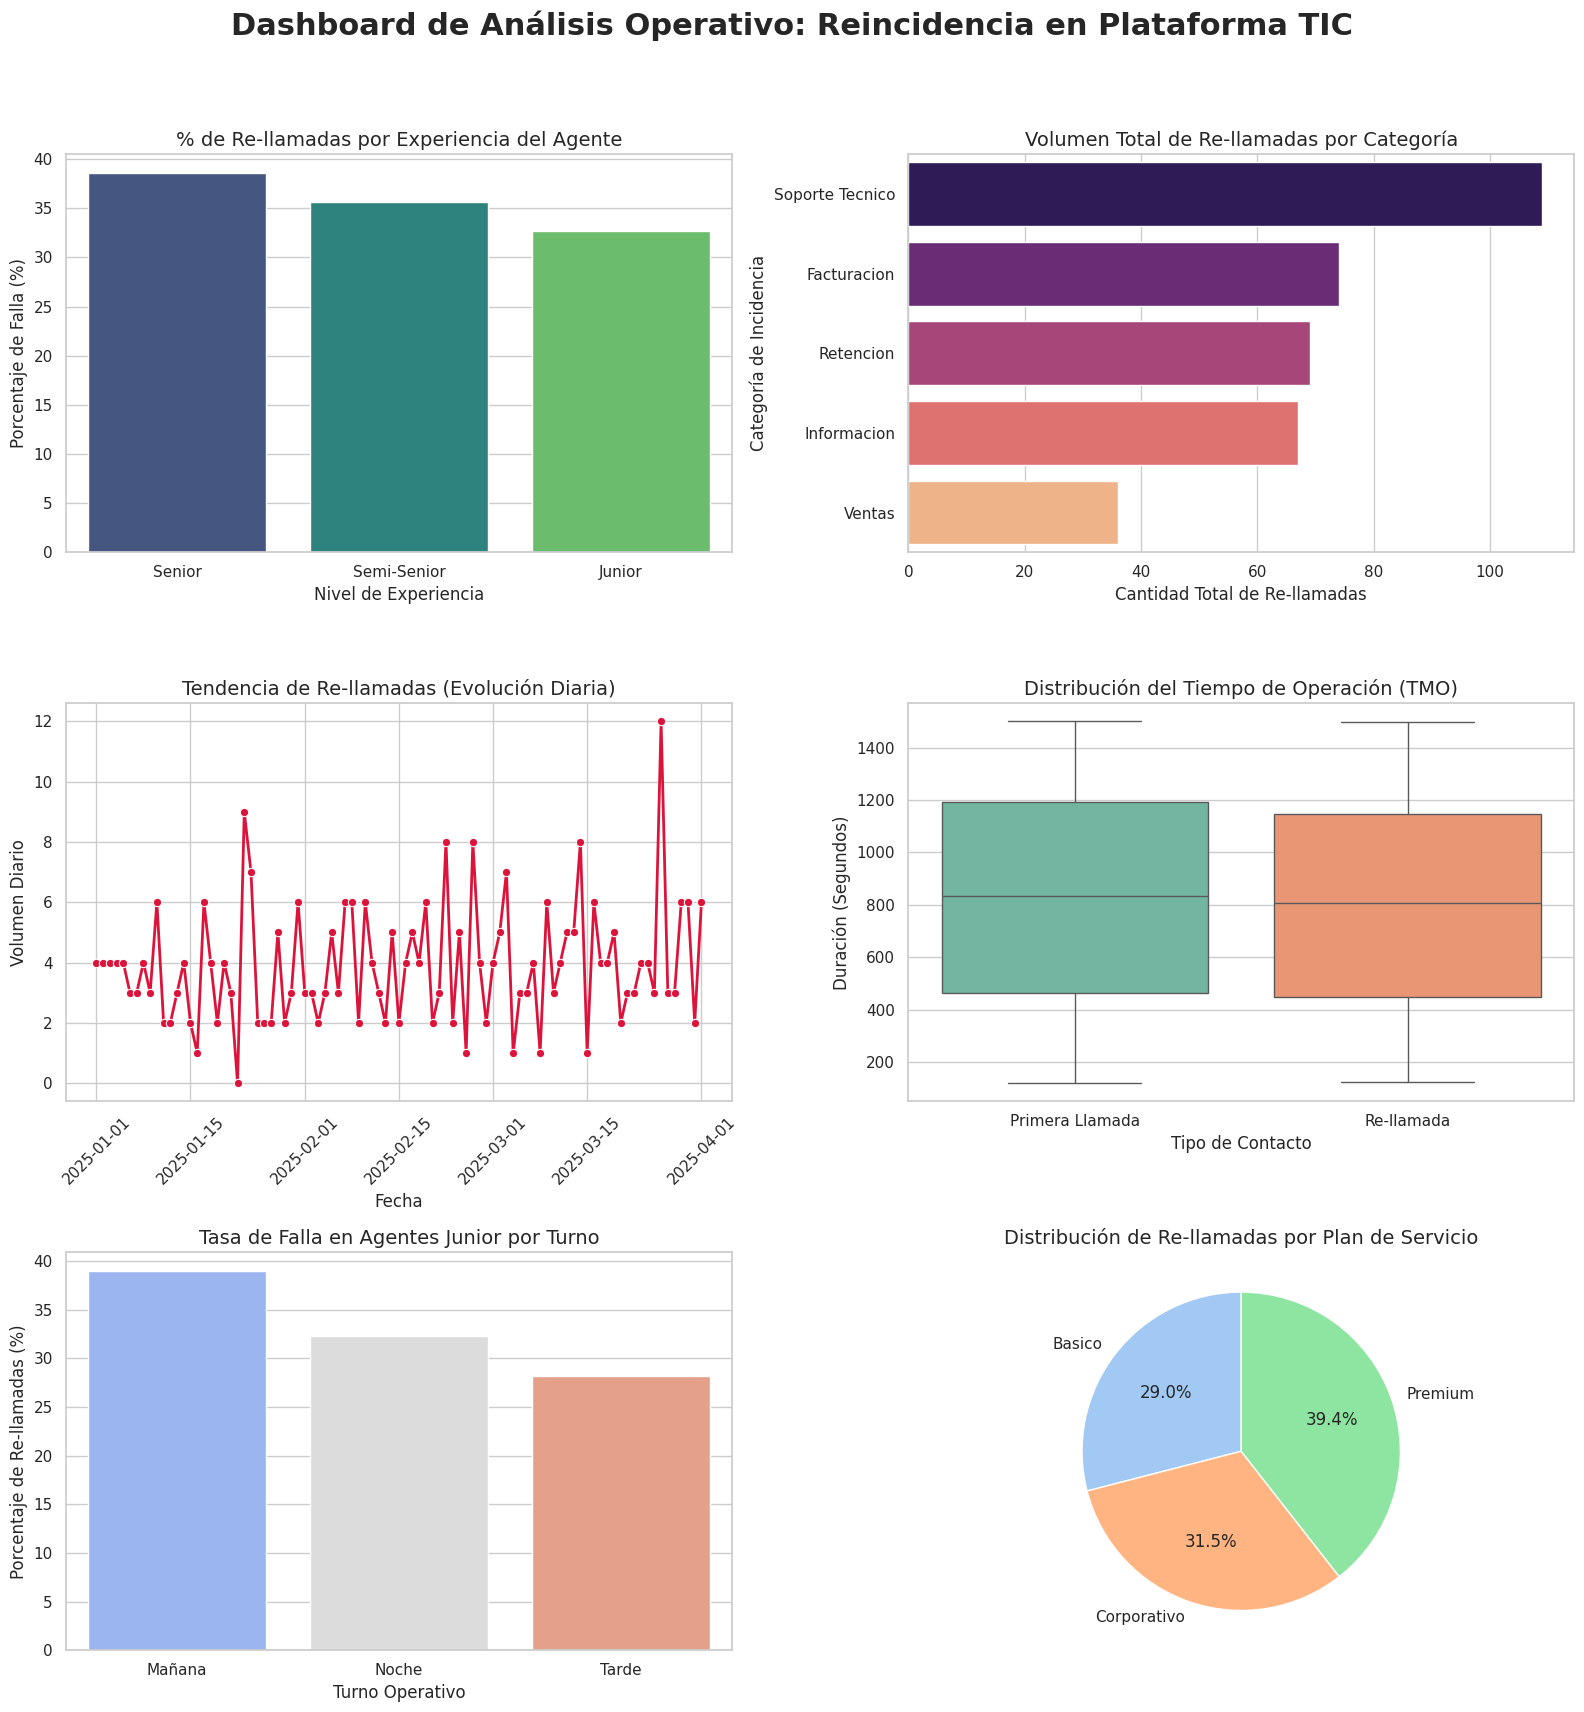

In [7]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual de los gráficos
sns.set_theme(style="whitegrid")

# Conectar a la base de datos
conn = sqlite3.connect('proyecto_tic.db')

# Crear una figura más grande para 6 subgráficos (3 filas x 2 columnas)
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Dashboard de Análisis Operativo: Reincidencia en Plataforma TIC', fontsize=22, fontweight='bold')

# -------------------------------------------------------------------------
# Gráfico 1 (Fila 1, Izq): % Re-llamadas por Experiencia (Barplot)
# -------------------------------------------------------------------------
query1 = """
    SELECT a.nivel_experiencia,
           (SUM(f.es_rellamada) * 100.0 / COUNT(f.id_interaccion)) as pct_rellamada
    FROM Fact_Interacciones f
    JOIN Dim_Agentes a ON f.id_agente = a.id_agente
    GROUP BY a.nivel_experiencia
    ORDER BY pct_rellamada DESC
"""
df1 = pd.read_sql_query(query1, conn)
sns.barplot(data=df1, x='nivel_experiencia', y='pct_rellamada', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('% de Re-llamadas por Experiencia del Agente', fontsize=14)
axes[0, 0].set_ylabel('Porcentaje de Falla (%)')
axes[0, 0].set_xlabel('Nivel de Experiencia')

# -------------------------------------------------------------------------
# Gráfico 2 (Fila 1, Der): Volumen de Re-llamadas por Categoría
# -------------------------------------------------------------------------
query2 = """
    SELECT t.categoria, SUM(f.es_rellamada) as total_rellamadas
    FROM Fact_Interacciones f
    JOIN Dim_Tipo_Incidencia t ON f.id_tipo_incidencia = t.id_tipo_incidencia
    GROUP BY t.categoria
    ORDER BY total_rellamadas DESC
"""
df2 = pd.read_sql_query(query2, conn)
sns.barplot(data=df2, x='total_rellamadas', y='categoria', ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('Volumen Total de Re-llamadas por Categoría', fontsize=14)
axes[0, 1].set_xlabel('Cantidad Total de Re-llamadas')
axes[0, 1].set_ylabel('Categoría de Incidencia')

# -------------------------------------------------------------------------
# Gráfico 3 (Fila 2, Izq): Tendencia Temporal (Líneas)
# -------------------------------------------------------------------------
query3 = """
    SELECT DATE(fecha_hora) as fecha, SUM(es_rellamada) as rellamadas
    FROM Fact_Interacciones
    GROUP BY DATE(fecha_hora)
    ORDER BY fecha
"""
df3 = pd.read_sql_query(query3, conn)
df3['fecha'] = pd.to_datetime(df3['fecha'])

sns.lineplot(data=df3, x='fecha', y='rellamadas', ax=axes[1, 0], marker='o', color='crimson', linewidth=2)
axes[1, 0].set_title('Tendencia de Re-llamadas (Evolución Diaria)', fontsize=14)
axes[1, 0].set_ylabel('Volumen Diario')
axes[1, 0].set_xlabel('Fecha')
axes[1, 0].tick_params(axis='x', rotation=45)

# -------------------------------------------------------------------------
# Gráfico 4 (Fila 2, Der): TMO Primera Llamada vs Re-llamada (Boxplot)
# -------------------------------------------------------------------------
query4 = """
    SELECT duracion_segundos,
           CASE WHEN es_rellamada = 1 THEN 'Re-llamada' ELSE 'Primera Llamada' END as tipo_contacto
    FROM Fact_Interacciones
"""
df4 = pd.read_sql_query(query4, conn)
sns.boxplot(data=df4, x='tipo_contacto', y='duracion_segundos', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Distribución del Tiempo de Operación (TMO)', fontsize=14)
axes[1, 1].set_ylabel('Duración (Segundos)')
axes[1, 1].set_xlabel('Tipo de Contacto')

# -------------------------------------------------------------------------
# Gráfico 5 (Fila 3, Izq): Tasa de Falla en Agentes Junior por Turno
# -------------------------------------------------------------------------
query5 = """
    SELECT a.turno,
           (SUM(f.es_rellamada) * 100.0 / COUNT(f.id_interaccion)) as tasa_falla
    FROM Fact_Interacciones f
    JOIN Dim_Agentes a ON f.id_agente = a.id_agente
    WHERE a.nivel_experiencia = 'Junior'
    GROUP BY a.turno
"""
df5 = pd.read_sql_query(query5, conn)
sns.barplot(data=df5, x='turno', y='tasa_falla', ax=axes[2, 0], palette='coolwarm')
axes[2, 0].set_title('Tasa de Falla en Agentes Junior por Turno', fontsize=14)
axes[2, 0].set_ylabel('Porcentaje de Re-llamadas (%)')
axes[2, 0].set_xlabel('Turno Operativo')

# -------------------------------------------------------------------------
# Gráfico 6 (Fila 3, Der): Re-llamadas por Plan de Servicio (Pie Chart)
# -------------------------------------------------------------------------
query6 = """
    SELECT u.plan_servicio, SUM(f.es_rellamada) as total_rellamadas
    FROM Fact_Interacciones f
    JOIN Dim_Usuarios u ON f.id_usuario = u.id_usuario
    WHERE f.es_rellamada = 1
    GROUP BY u.plan_servicio
"""
df6 = pd.read_sql_query(query6, conn)
axes[2, 1].pie(df6['total_rellamadas'], labels=df6['plan_servicio'], autopct='%1.1f%%',
               startangle=90, colors=sns.color_palette('pastel'))
axes[2, 1].set_title('Distribución de Re-llamadas por Plan de Servicio', fontsize=14)

# Ajustar el espaciado para que nada se superponga y mostrar el gráfico
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Cerrar la conexión
conn.close()

In [8]:
!pip install -q streamlit
!npm install localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 84.5 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
added 22 packages in 3s
⠙
⠙3 packages are looking for funding
⠙  run `npm fund` for details
⠙

In [17]:
import streamlit as st
import pandas as pd
import sqlite3
import plotly.express as px

# -------------------------------------------------------------------------
# 1. CONFIGURACIÓN DE PÁGINA Y ESTILOS
# -------------------------------------------------------------------------
st.set_page_config(page_title="Control Tower - TIC", layout="wide", page_icon="📡")

# Inyectar CSS personalizado para mejorar el diseño de las métricas
st.markdown("""
<style>
    .metric-card {
        background-color: #ffffff;
        border-radius: 10px;
        padding: 20px;
        box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);
        border-left: 5px solid #1f77b4;
    }
</style>
""", unsafe_allow_html=True)

# Banner de imagen superior (usando una imagen pública de Unsplash para darle un toque pro)
st.image("https://images.unsplash.com/photo-1551288049-bebda4e38f71?auto=format&fit=crop&w=2000&q=80", use_container_width=True)

st.title("📡 Control Tower: Análisis de Reincidencia TIC")
st.markdown("Plataforma interactiva para el monitoreo de resolución en primer contacto (FCR) y comportamiento de re-llamadas. Proyecto Final Talento Tech.")
st.markdown("---")

# -------------------------------------------------------------------------
# 2. CARGA Y PREPARACIÓN DE DATOS
# -------------------------------------------------------------------------
@st.cache_data
def load_data():
    conn = sqlite3.connect('proyecto_tic.db')
    query = """
        SELECT
            f.id_interaccion, f.fecha_hora, u.plan_servicio, a.nivel_experiencia,
            a.turno, t.categoria, t.prioridad, f.duracion_segundos,
            f.resuelta_en_primera_llamada, f.es_rellamada,
            CASE
                WHEN u.fecha_registro >= '2025-01-01' THEN 'A: Clientes nuevos'
                WHEN f.duracion_segundos = 0 THEN 'B: No contacto'
                WHEN f.duracion_segundos > 180 THEN 'C: Contacto con TMO > 3 Min'
                ELSE 'D: restantes'
            END AS segmento_operativo
        FROM Fact_Interacciones f
        JOIN Dim_Usuarios u ON f.id_usuario = u.id_usuario
        JOIN Dim_Agentes a ON f.id_agente = a.id_agente
        JOIN Dim_Tipo_Incidencia t ON f.id_tipo_incidencia = t.id_tipo_incidencia
    """
    df = pd.read_sql_query(query, conn)
    conn.close()

    # Asegurar formato de fecha para gráficas temporales
    df['fecha_hora'] = pd.to_datetime(df['fecha_hora'])
    df['fecha_dia'] = df['fecha_hora'].dt.date
    return df

df = load_data()

# -------------------------------------------------------------------------
# 3. BARRA LATERAL (SIDEBAR) - FILTROS AVANZADOS
# -------------------------------------------------------------------------
st.sidebar.image("https://cdn-icons-png.flaticon.com/512/8633/8633190.png", width=120)
st.sidebar.header("🎯 Segmentación Dinámica")
st.sidebar.markdown("Usa estos filtros para explorar distintos escenarios.")

# Multiselects
turnos = st.sidebar.multiselect("⌚ Turno Operativo:", options=df['turno'].unique(), default=df['turno'].unique())
experiencia = st.sidebar.multiselect("🎖️ Nivel de Experiencia:", options=df['nivel_experiencia'].unique(), default=df['nivel_experiencia'].unique())
prioridad = st.sidebar.multiselect("🚨 Prioridad del Caso:", options=df['prioridad'].unique(), default=df['prioridad'].unique())
segmentos = st.sidebar.multiselect("📊 Segmento Operativo:", options=df['segmento_operativo'].unique(), default=df['segmento_operativo'].unique())

# Aplicar todos los filtros al DataFrame
df_filtrado = df[
    (df['turno'].isin(turnos)) &
    (df['nivel_experiencia'].isin(experiencia)) &
    (df['prioridad'].isin(prioridad)) &
    (df['segmento_operativo'].isin(segmentos))
]

# -------------------------------------------------------------------------
# 4. KPIs PRINCIPALES (Tarjetas)
# -------------------------------------------------------------------------
if len(df_filtrado) == 0:
    st.warning("⚠️ No hay datos para los filtros seleccionados. Por favor ajusta tu búsqueda.")
else:
    col1, col2, col3, col4 = st.columns(4)

    total_casos = len(df_filtrado)
    tasa_re = (df_filtrado['es_rellamada'].sum() / total_casos) * 100
    tmo_prom = df_filtrado['duracion_segundos'].mean() / 60
    fcr_pct = (df_filtrado['resuelta_en_primera_llamada'].sum() / total_casos) * 100

    col1.metric("📞 Interacciones Atendidas", f"{total_casos:,}", "Volumen total")
    col2.metric("⚠️ Tasa de Reincidencia", f"{tasa_re:.1f}%", "- Objetivo: < 15%", delta_color="inverse")
    col3.metric("⏱️ TMO Promedio", f"{tmo_prom:.1f} min", "Tiempo de operación")
    col4.metric("✅ Resolución 1er Contacto", f"{fcr_pct:.1f}%", "+ Objetivo: > 70%")

    st.markdown("<br>", unsafe_allow_html=True)

    # -------------------------------------------------------------------------
    # 5. TABS DE ANÁLISIS (Pestañas organizadas)
    # -------------------------------------------------------------------------
    tab1, tab2, tab3 = st.tabs(["📈 Análisis de Reincidencia", "👥 Rendimiento Operativo", "📋 Base de Datos"])

    with tab1:
        st.subheader("Drivers de Re-llamadas")
        c1, c2 = st.columns(2)

        with c1:
            # Gráfico de Barras: Volumen por Categoría
            df_re = df_filtrado[df_filtrado['es_rellamada'] == 1]
            fig1 = px.histogram(df_re, y='categoria', color='prioridad',
                                title="Volumen de Re-llamadas por Categoría y Prioridad",
                                template="plotly_white", barmode='stack')
            fig1.update_layout(yaxis={'categoryorder':'total ascending'})
            st.plotly_chart(fig1, use_container_width=True)

        with c2:
            # Heatmap de Riesgo (Cruce de Prioridad vs Experiencia)
            matriz_riesgo = df_filtrado.pivot_table(index='prioridad', columns='nivel_experiencia',
                                                    values='es_rellamada', aggfunc='mean') * 100
            fig2 = px.imshow(matriz_riesgo, text_auto=".1f", aspect="auto", color_continuous_scale='Reds',
                             title="Matriz de Riesgo: % Reincidencia (Prioridad vs Experiencia)")
            st.plotly_chart(fig2, use_container_width=True)

        # Gráfico de Línea: Evolución temporal
        df_tendencia = df_filtrado.groupby('fecha_dia')['es_rellamada'].sum().reset_index()
        fig3 = px.line(df_tendencia, x='fecha_dia', y='es_rellamada', markers=True,
                       title="Evolución Temporal de Re-llamadas Diarias", template="plotly_white", color_discrete_sequence=['#e63946'])
        st.plotly_chart(fig3, use_container_width=True)

    with tab2:
        st.subheader("Análisis de Tiempos y Esfuerzo")
        c3, c4 = st.columns(2)

        with c3:
            # Boxplot de TMO
            fig4 = px.box(df_filtrado, x='segmento_operativo', y='duracion_segundos', color='turno',
                          title="Dispersión del TMO por Segmento Operativo", template="plotly_white")
            st.plotly_chart(fig4, use_container_width=True)

        with c4:
            # Pie chart: Distribución de esfuerzo
            fig5 = px.pie(df_filtrado, names='plan_servicio', values='duracion_segundos',
                          title="Tiempo Total Invertido por Plan de Servicio", hole=0.3, template="plotly_white")
            st.plotly_chart(fig5, use_container_width=True)

    with tab3:
        st.subheader("Extracción de Datos")
        st.markdown("Visualiza y descarga el dataset consolidado basado en los filtros aplicados.")
        st.dataframe(df_filtrado.sort_values('fecha_hora', ascending=False), use_container_width=True)

2026-03-27 02:29:47.883 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-27 02:29:47.886 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-27 02:29:48.104 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-27 02:29:48.105 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-27 02:29:48.106 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-27 02:29:48.108 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='c

In [16]:
%%writefile requirements.txt
streamlit
pandas
plotly

Writing requirements.txt
